# First of all to build a model we will need to import some required libraries.
> we will be analizing and visualizing the data with the help of graphs as well.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
cf.go_offline()
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

/opt/conda/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning:

The Shapely GEOS version (3.9.1-CAPI-1.14.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.



## Reding and visualizing the data

In [2]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')
submission = pd.read_csv('../input/titanic/gender_submission.csv')

In [3]:
train.head()  # by default head gives us first 5 rows from our dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# checking total missing values in our data
len(train.isna())

891

<AxesSubplot:>

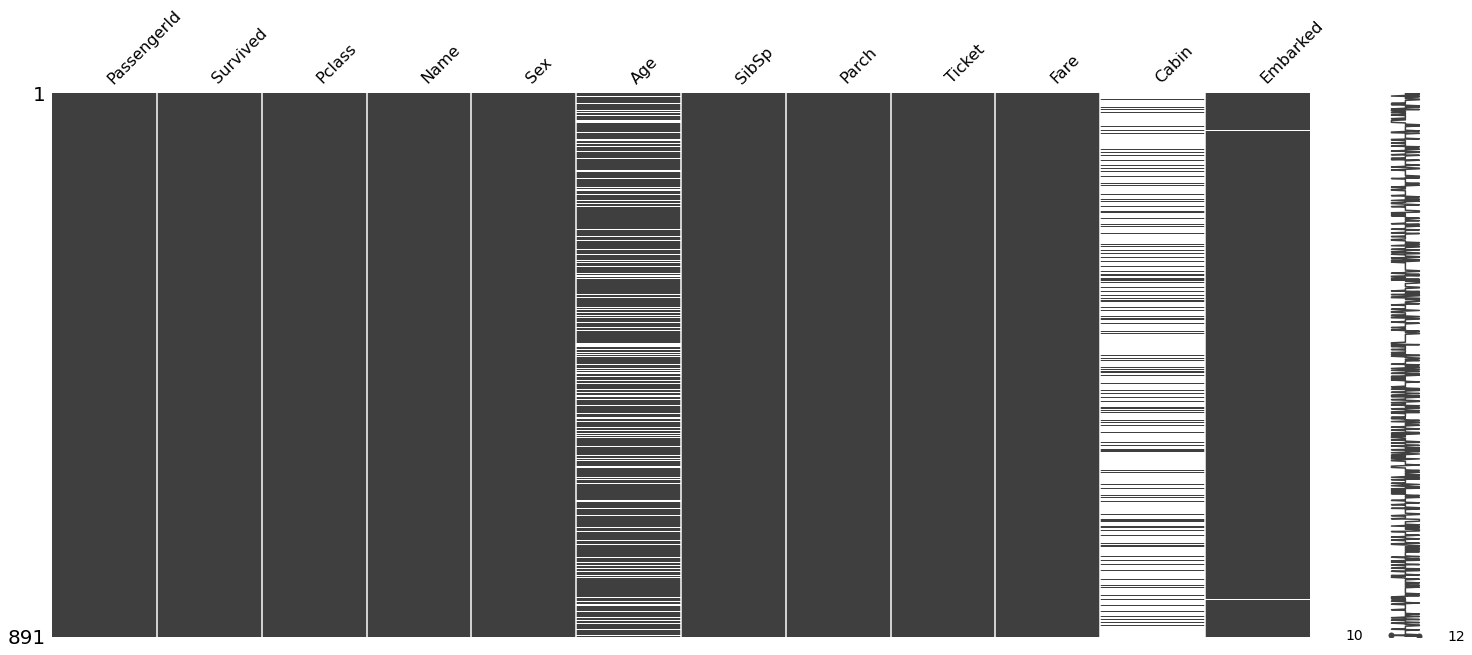

In [6]:
# Visualizing missing values through the graph
import missingno
missingno.matrix(train)

> From the above graph we clearly see that there are a lot of missing values in age and cabin columns. And we will try to fix those ahead.

In [7]:
train['Survived'].iplot(kind='hist')

In [8]:
# checking number of male and female passingers 
train.pivot(columns='Sex', values='Sex').iplot(kind='hist', title = 'Gender count', yTitle ='Number of people', xTitle='Gender')

In [9]:
# checking Fare for each pasinger calss
train.pivot(columns='Pclass', values='Fare').iplot(kind='box', xTitle= 'Passenger Class',yTitle='Fare')

In [10]:
# chekcing age per class
train.pivot(columns='Pclass', values='Age').iplot(kind='box', xTitle= 'Passenger Class',yTitle='Age', title = "Age according to passenger class")

In [11]:
# checking the age of most and if it forms bells curve
train['Age'].dropna().iplot(kind='hist', bins=30, xTitle = "Age", yTitle='Number of People',title ='Age Graph')

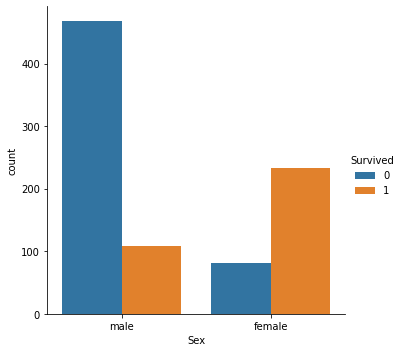

In [12]:
# survived and dead by gender
sns.catplot(x ="Sex", hue ="Survived",kind ="count", data = train)

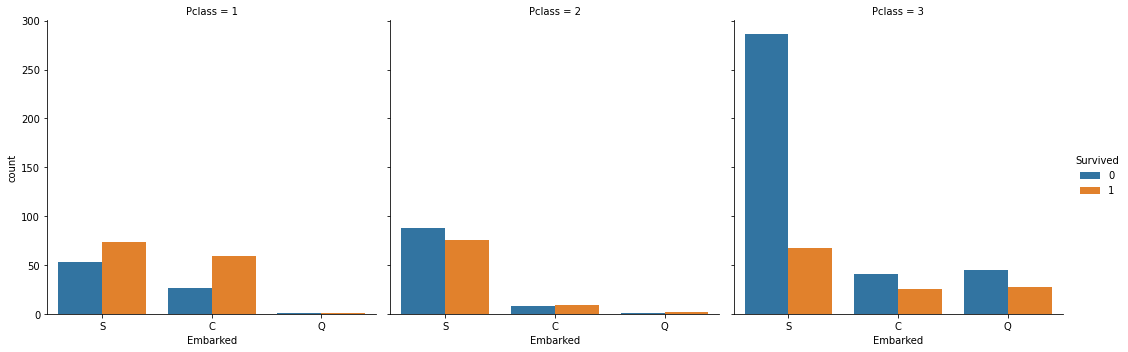

In [13]:
# checking survival rate by embraked and passener
sns.catplot(x ='Embarked', hue ='Survived',kind ='count', col ='Pclass', data = train)

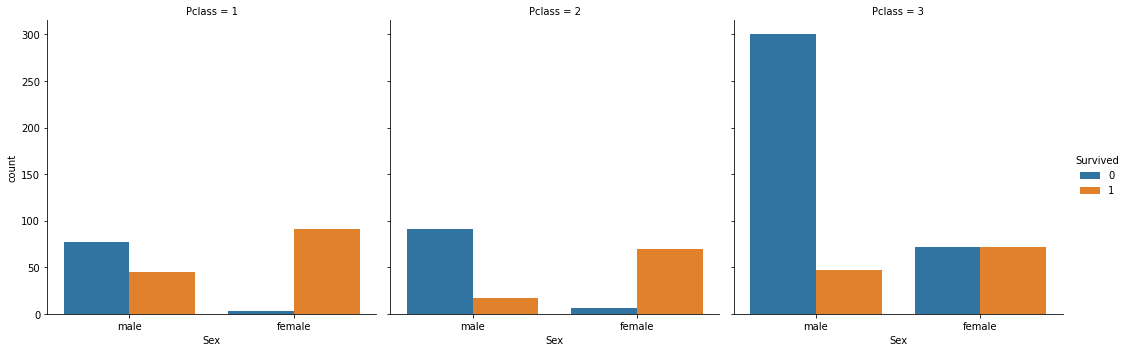

In [14]:
# pclass vs Survivd graphs
sns.catplot(x ='Sex', hue ='Survived',kind ='count', col ='Pclass', data = train)

In [15]:
# defining a function to fill all the missing age values 
def fill_age(cols):
    Age=cols[0]
    Pclass=cols[1]
    if pd.isnull(Age): 
        if Pclass == 1:
            return 37 # 37 is avg age as it can be seen in box plot for pasinger in Pclass 1
        if Pclass == 2:
            return 29 # 29 is avg age as it can be seen in box plot for pasinger in Pclass 1
        if Pclass == 3:
            return 24 # 24 is avg age as it can be seen in box plot for pasinger in Pclass 1
    else:
        return Age

In [16]:
# Applying the above funcation in our train and test data sets
train['Age'] = train[['Pclass','Age']].apply(fill_age,axis=1)
test['Age'] = test[['Pclass','Age']].apply(fill_age,axis=1)

In [17]:
# One hot encoding sex column (converting it into 0 and 1)
sex1 = pd.get_dummies(train['Sex'],drop_first=True)
sex2 = pd.get_dummies(test['Sex'],drop_first=True)

In [18]:
# similarly one hot encoding embarked data
embarked1 = pd.get_dummies(train['Embarked'],drop_first=True)
embarked2 = pd.get_dummies(test['Embarked'],drop_first=True)

In [19]:
# One hot encodung parch column as well
parch1 = pd.get_dummies(train['Parch'],drop_first=True)
parch2 = pd.get_dummies(test['Parch'],drop_first=True)

## Now we need to drop Unwanted data and add One Hot encoded data

In [20]:
train.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,3.0,1,0,A/5 21171,7.25,NaN,S


In [21]:
#dropping columns
train.drop(['PassengerId','Name','Sex','Ticket','Cabin','Embarked'],inplace =True, axis=1)
test.drop(['PassengerId','Name','Sex','Ticket','Cabin','Embarked'],inplace =True, axis=1)

In [22]:
# adding one hot encoded values
train = pd.concat([train,sex1,embarked1,parch1],axis=1)
test = pd.concat([test,sex2,embarked2,parch2],axis=1)

In [23]:
test.drop([9],axis=1,inplace=True)

In [24]:
# normalizing the values 
train['Age']=np.log(train['Age'])
test['Age']=np.log(test['Age'])

In [25]:
train

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S,1,2,3,4,5,6
0,0,3,1.098612,1,0,7.2500,1,0,1,0,0,0,0,0,0
1,1,1,0.000000,1,0,71.2833,0,0,0,0,0,0,0,0,0
2,1,3,1.098612,0,0,7.9250,0,0,1,0,0,0,0,0,0
3,1,1,0.000000,1,0,53.1000,0,0,1,0,0,0,0,0,0
4,0,3,1.098612,0,0,8.0500,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0.693147,0,0,13.0000,1,0,1,0,0,0,0,0,0
887,1,1,0.000000,0,0,30.0000,0,0,1,0,0,0,0,0,0
888,0,3,1.098612,1,2,23.4500,0,0,1,0,1,0,0,0,0
889,1,1,0.000000,0,0,30.0000,1,0,0,0,0,0,0,0,0


<AxesSubplot:>

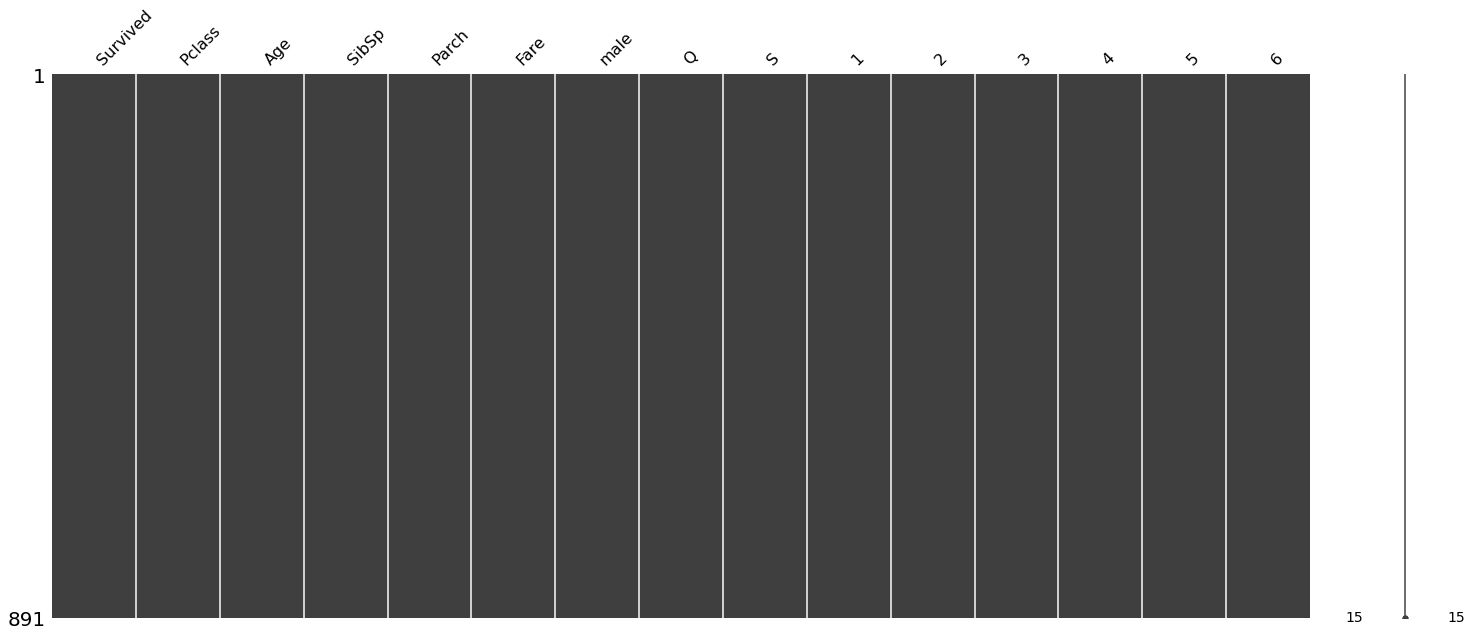

In [26]:
# checnking again if we have missing values 
missingno.matrix(train)

## Creating training and testing data sets

In [27]:
x = train.drop(['Survived'], axis=1)
y = train['Survived']

In [28]:
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=4)

## Creating model:
> We will use the XGBoost for the classification. We don’t know the best parameters for our model, so we will let GridSearchCV find them for us. We will just define the parameter range for GridSearchCV to search within.

In [29]:
 #Defining the parameters to search within
param_grid = {
'n_estimators': range(6, 10),
'max_depth': range(3, 8),
'learning_rate': [.2, .3, .4],
'colsample_bytree': [.7, .8, .9, 1]
}
#Specifying our classifier
xgb = XGBClassifier()
#Searching for the best parameters
g_search = GridSearchCV(estimator = xgb, param_grid = param_grid,
cv = 3, n_jobs = 1, verbose = 0, return_train_score=True)
#Fitting the model using best parameters found
g_search.fit(x_train, y_train)
#Printing the best parameters found
print(g_search.best_params_)

{'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 9}


In [30]:
#Calculating the model's score
g_search.score(x_test,y_test)

0.8100558659217877

## Predicting and Creating Sample_submission

In [31]:
pred = g_search.predict(test)

In [32]:
submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [33]:
pred = pd.Series(pred, name='Survived')
submission['Survived'] = pred
submission.to_csv('submission.csv',index=False)